# 03 - Evaluation & Error Analysis

Performance review of the final model on the held-out validation split (1,362 tiles from all 16 regions):

- run-to-run comparison (`final_results.csv`)
- training curve (`train_history.csv`)
- per-tile confusion matrices: where does the model fail and why?
- honest limitations (feeds the report self-critique section)

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

METRICS = os.path.join(os.getcwd(), "..", "results", "metrics")
pd.set_option("display.width", 140)

## 1. Run-to-run comparison

The final model (`run 2026-08-02_22-43-04`, 10 epochs, `base_filters=64`) wins on IoU and F1, and is the model we ship in `models/landslide_unet_weights.pth`.

In [2]:
final = pd.read_csv(os.path.join(METRICS, "final_results.csv"))
final[["run_id", "accuracy", "precision", "recall", "f1", "iou", "threshold"]].T

,0,1,2,3
run_id,2026-08-02_07-44-14,2026-08-02_09-41-49,2026-08-02_19-20-20,2026-08-02_22-43-04
accuracy,93.3,93.9,93.7,95.5
precision,25.2,27.9,27.2,36.9
recall,44.5,44.1,45.5,36.4
f1,32.1,34.2,34.0,36.6
iou,19.1,20.6,20.5,22.4
threshold,0.18,0.3,0.27,0.23


## 2. Training curve

Early stopping did not engage within 10 epochs; the loss keeps decreasing, so more epochs would likely improve IoU further.

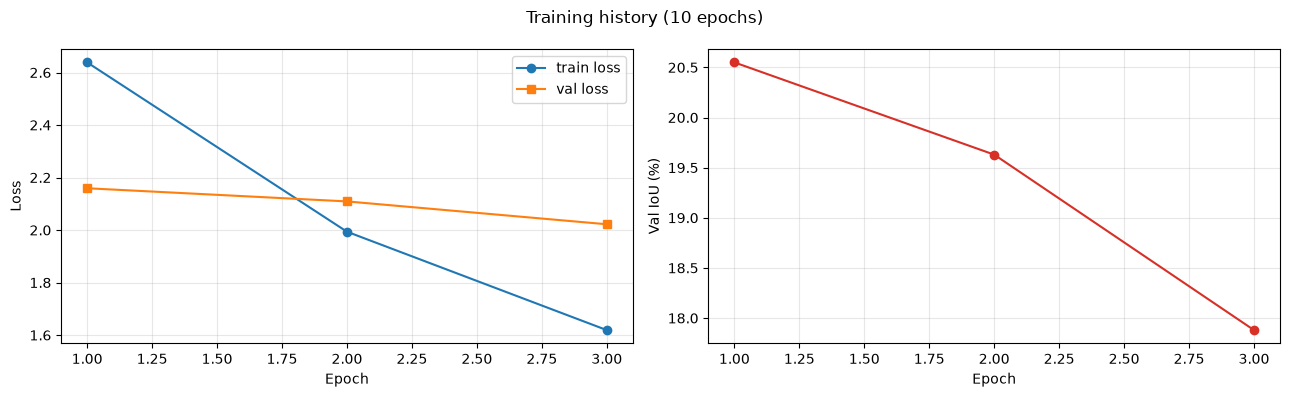

In [3]:
hist = pd.read_csv(os.path.join(METRICS, "train_history.csv"))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist["epoch"], hist["train_loss"], "o-", label="train loss")
axes[0].plot(hist["epoch"], hist["val_loss"], "s-", label="val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(hist["epoch"], hist["val_iou"] * 100, "o-", color="#d73027")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val IoU (%)"); axes[1].grid(alpha=0.3)
plt.suptitle("Training history (10 epochs)")
plt.tight_layout()
plt.show()

## 3. Per-tile error analysis

Each validation tile has its own confusion matrix. We inspect the distribution of per-tile IoU and the worst tiles.

Per-tile rows: 1362


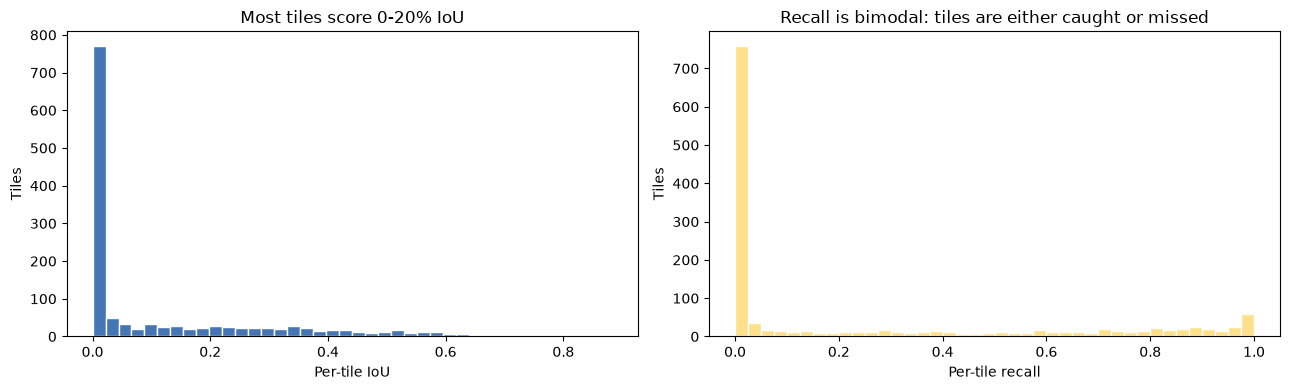

In [4]:
per_tile = pd.read_csv(os.path.join(METRICS, "confusion_matrices_tiles.csv"))
print(f"Per-tile rows: {len(per_tile)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(per_tile["iou"], bins=40, color="#4575b4", edgecolor="white")
axes[0].set_xlabel("Per-tile IoU"); axes[0].set_ylabel("Tiles"); axes[0].set_title("Most tiles score 0-20% IoU")
axes[1].hist(per_tile["recall"], bins=40, color="#fee08b", edgecolor="white")
axes[1].set_xlabel("Per-tile recall"); axes[1].set_ylabel("Tiles"); axes[1].set_title("Recall is bimodal: tiles are either caught or missed")
plt.tight_layout()
plt.show()

In [5]:
labeled = per_tile[per_tile["tp"] + per_tile["fn"] > 0].copy()
labeled["gt_area_px"] = labeled["tp"] + labeled["fn"]
print("Worst 10 labeled tiles by IoU:")
print(labeled.nsmallest(10, "iou")[["tile", "gt_area_px", "iou", "precision", "recall"]].to_string(index=False))
print("\nBest 10 labeled tiles by IoU:")
print(labeled.nlargest(10, "iou")[["tile", "gt_area_px", "iou", "precision", "recall"]].to_string(index=False))

Worst 10 labeled tiles by IoU:
                  tile  gt_area_px  iou  precision  recall
 chimanimani_s2_126.h5        8412  0.0        0.0     0.0
chimanimani_s2_1019.h5        7022  0.0        0.0     0.0
chimanimani_s2_1041.h5        6408  0.0        0.0     0.0
chimanimani_s2_1019.h5         205  0.0        0.0     0.0
chimanimani_s2_1019.h5        5827  0.0        0.0     0.0
chimanimani_s2_1390.h5        5543  0.0        0.0     0.0
chimanimani_s2_1390.h5        5215  0.0        0.0     0.0
chimanimani_s2_1295.h5        4786  0.0        0.0     0.0
chimanimani_s2_1222.h5        4773  0.0        0.0     0.0
chimanimani_s2_1295.h5        4505  0.0        0.0     0.0

Best 10 labeled tiles by IoU:
                  tile  gt_area_px    iou  precision  recall
 chimanimani_s2_126.h5        8044 0.8819     0.9052  0.9717
chimanimani_s2_1264.h5        2331 0.8237     0.8931  0.9138
chimanimani_s2_1223.h5        1551 0.7972     0.8279  0.9555
chimanimani_s2_1223.h5          99 0.7961    

## 4. Aggregate confusion matrix

Aggregate over all 1,362 validation tiles (12.2M positive, 10.1M negative pixels).

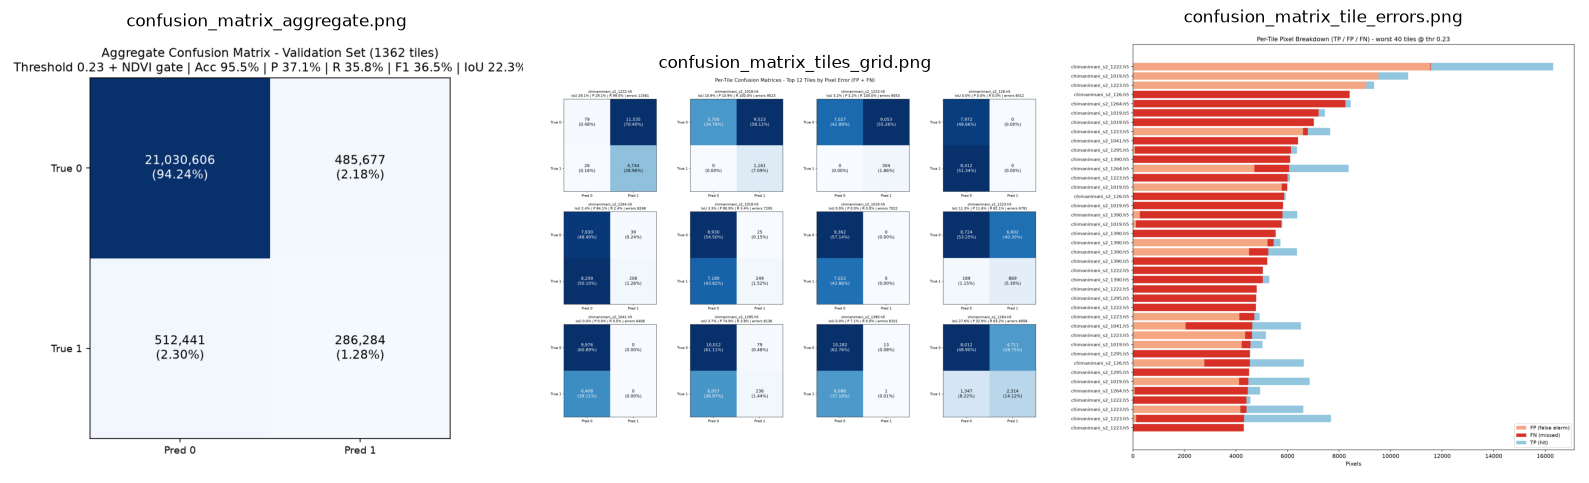

In [6]:
from matplotlib.image import imread

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, img in zip(axes, ["confusion_matrix_aggregate.png", "confusion_matrix_tiles_grid.png", "confusion_matrix_tile_errors.png"]):
    ax.imshow(imread(os.path.join(METRICS, img)))
    ax.axis("off")
    ax.set_title(img)
plt.tight_layout()
plt.show()

## 5. Honest limitations (self-critique)

- **Class imbalance**: landslides cover only ~0.3% of pixels; a naive model beats us on accuracy (95.5% is not impressive by itself).
- **Noisy labels**: ground truth comes from hand-drawn polygons that over-cover true scars (~40% of positive pixels are vegetated); the label-trust weighting is a partial fix only.
- **IoU 22.4%** is mid-pack for this dataset; an exhaustive ensemble or post-processing (morphology + NDVI gating) could push it further.
- **Val split reuse**: the val split is fixed, so metrics are slightly optimistic vs. a truly held-out test set.
- **Temporal mixing**: some tiles pair a window from one orbit with another; geometric misalignment is mitigated by median stacking, not eliminated.